In [31]:
import matplotlib.pyplot as plt
import matplotlib.colors as mscolors
import matplotlib.font_manager as fm
from matplotlib.cm import ScalarMappable

import pandas as pd
import geopandas as gpd
import numpy as np

In [32]:
COMUNAS_URBANAS = {
    "13124": "Pudahuel",
    "13103": "Cerro Navia",
    "13104": "Conchalí",
    "13112": "La Pintana",
    "13105": "El Bosque",
    "13106": "Estación Central",
    "13121": "Pedro Aguirre Cerda",
    "13127": "Recoleta",
    "13108": "Independencia",
    "13110": "La Florida",
    "13122": "Peñalolén",
    "13114": "Las Condes",
    "13115": "Lo Barnechea",
    "13126": "Quinta Normal",
    "13119": "Maipú",
    "13118": "Macul",
    "13120": "Ñuñoa",
    "13201": "Puente Alto",
    "13125": "Quilicura",
    "13128": "Renca",
    "13401": "San Bernardo",
    "13130": "San Miguel",
    "13111": "La Granja",
    "13123": "Providencia",
    "13101": "Santiago",
    "13129": "San Joaquín",
    "13116": "Lo Espejo",
    "13113": "La Reina",
    "13131": "San Ramón",
    "13109": "La Cisterna",
    "13117": "Lo Prado",
    "13102": "Cerrillos",
    "13132": "Vitacura",
    "13107": "Huechuraba",
    "13203": "San José de Maipo",
}

ISLAS_URBANAS = {
    "13124071004", "13124071005", "13124081001",
    "13124071001", "13124071002", "13124071003",   # Pudahuel
    "13401121001",                                  # San Bernardo
    "13119131001",                                  # Maipú
    "13203031000", "13203031001", "13203031002",
    "13203011001", "13203011002"                   # San José de Maipo
}

In [33]:
gdf = gpd.read_file("r13_zonas.geojson")
gdf = gdf[gdf['codigo_comuna'].isin(COMUNAS_URBANAS.keys()) & ~gdf["geocodigo"].isin(ISLAS_URBANAS)].copy()
# gdf = gdf[gdf['codigo_comuna'].isin(COMUNAS_URBANAS.keys())].copy()
gdf_proj = gdf.to_crs("EPSG:32719")
gdf_proj['area_km2'] = gdf_proj.geometry.area / 1e6
gdf_proj['densidad'] = 1 / gdf_proj['area_km2']

p99 = gdf_proj['densidad'].quantile(0.99)
gdf_proj['densidad_clipped'] = gdf_proj['densidad'].clip(upper=p99)


# Comunas bordes + centros por labels
comunas = gdf_proj.dissolve(by='codigo_comuna').reset_index()
comunas['nombre'] = comunas['codigo_comuna'].map(COMUNAS_URBANAS)
# comunas['nombre'] = comunas['codigo_comuna']

print(f"Zonas filtradas: {len(gdf_proj)}")
print(f"Comunas: {len(comunas)}")

Zonas filtradas: 1638
Comunas: 35


Para el html


In [34]:
gdf_wgs = gdf_proj.to_crs("EPSG:4326")
gdf_wgs['nombre_comuna'] = gdf_wgs['codigo_comuna'].map(COMUNAS_URBANAS)

# Exportar
gdf_wgs[['geocodigo', 'codigo_comuna', 'nombre_comuna', 'densidad', 'geometry']]\
    .to_file("zonas_densidad.geojson", driver="GeoJSON")

Muestra para python

In [35]:
comunas = gdf_proj.dissolve(by='codigo_comuna').reset_index()
comunas['nombre'] = comunas['codigo_comuna'].map(COMUNAS_URBANAS)
comunas['centroid_x'] = comunas.geometry.centroid.x
comunas['centroid_y'] = comunas.geometry.centroid.y

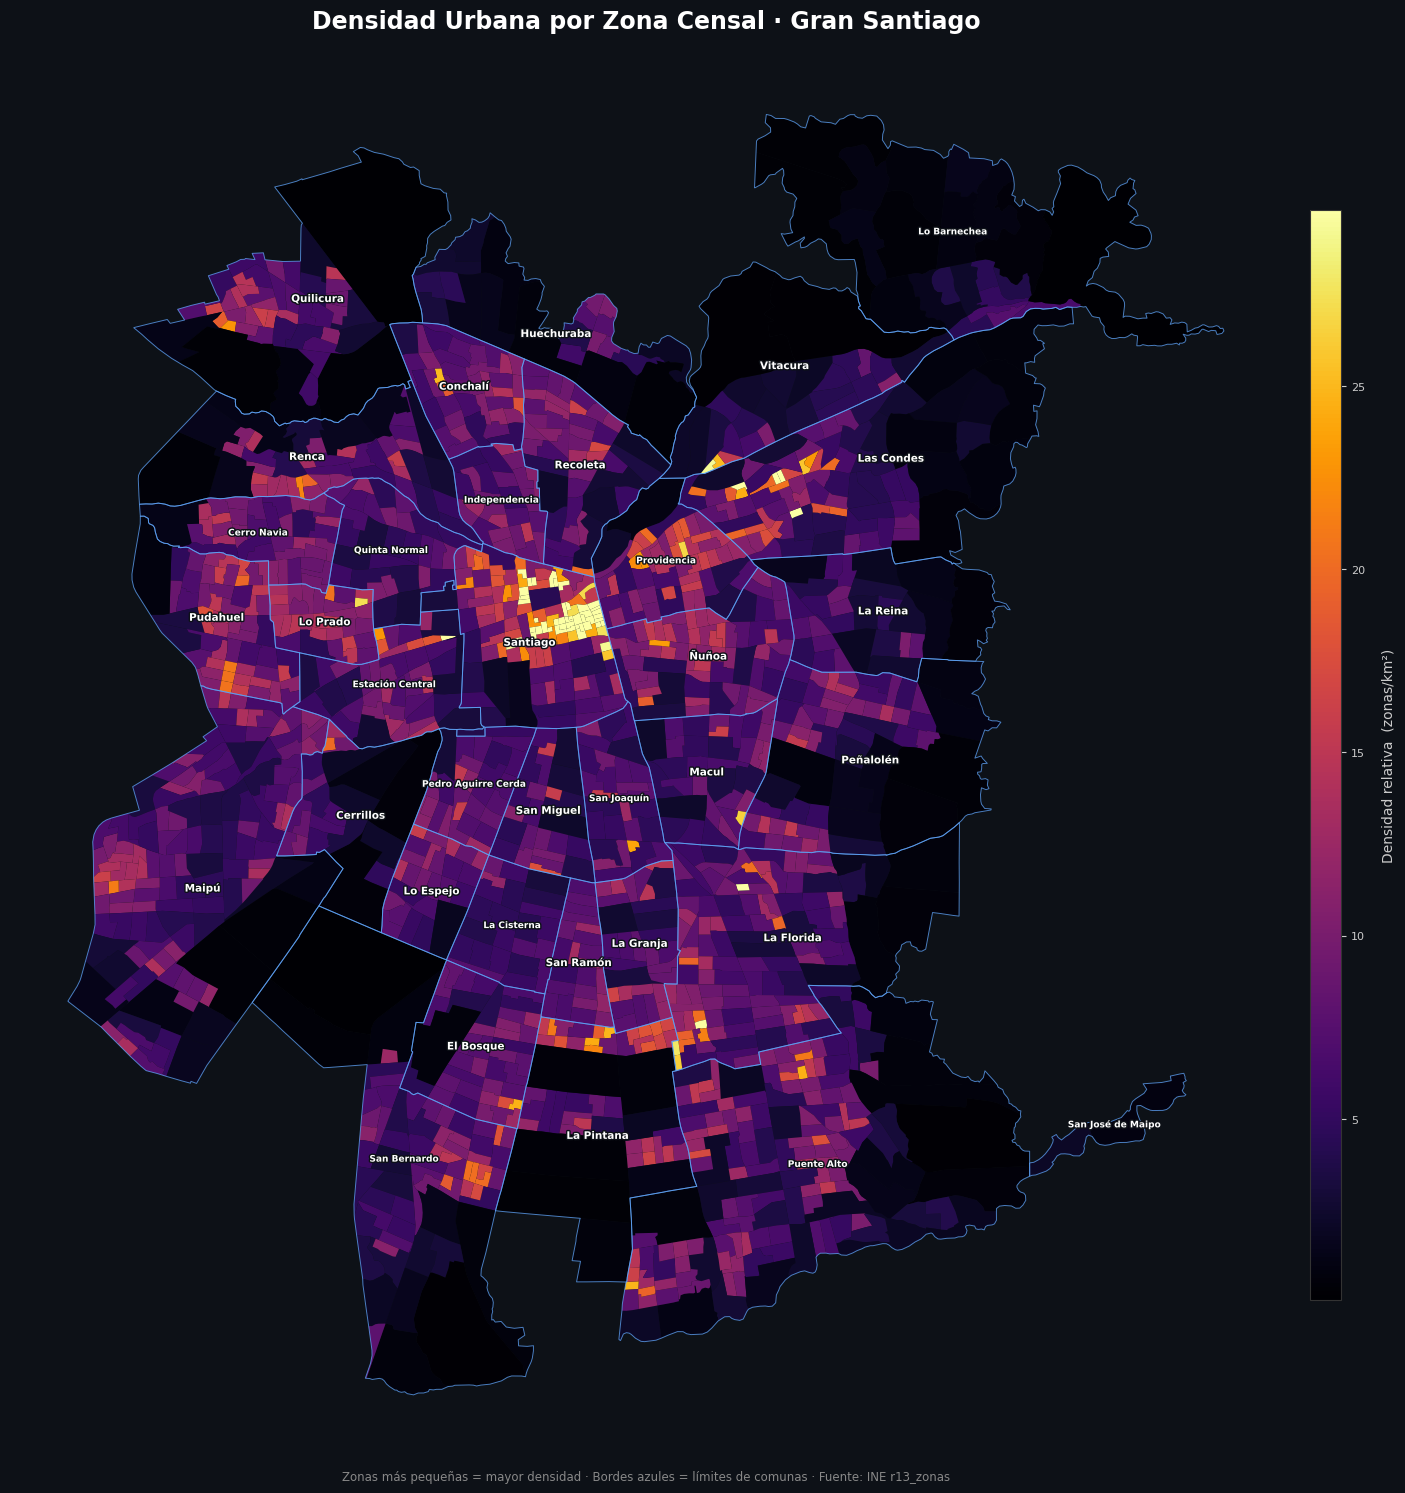

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# CMAP = "hot"
CMAP = "inferno"

gdf_proj.plot(
    column='densidad_clipped',
    ax=ax,
    cmap=CMAP,
    linewidth=0,
    legend=False,
    vmin=gdf_proj['densidad_clipped'].min(),
    vmax=gdf_proj['densidad_clipped'].max() - 17,
)

# Comuna bordes
comunas.boundary.plot(ax=ax, color='#60a5fa', linewidth=0.7, alpha=0.75)

# Labels
for _, row in comunas.iterrows():
    code = row['codigo_comuna']
    x = row['centroid_x']
    y = row['centroid_y']
    nombre = row['nombre']
    fontsize = 6.5 if len(nombre) > 10 else 7.5
    ax.text(x, y, nombre,
            ha='center', va='center',
            fontsize=fontsize, color='white',
            fontweight='bold',
            path_effects=[
                __import__('matplotlib.patheffects', fromlist=['withStroke'])
                .withStroke(linewidth=2, foreground='#0d1117')
            ])

# Colorbar
sm = ScalarMappable(cmap=CMAP,
                    norm=plt.Normalize(vmin=gdf_proj['densidad_clipped'].min(),
                                       vmax=gdf_proj['densidad_clipped'].max()))
cbar = fig.colorbar(sm, ax=ax, fraction=0.022, pad=0.02, aspect=35)
cbar.set_label('Densidad relativa  (zonas/km²)', color='#cccccc', fontsize=10, labelpad=12)
cbar.ax.yaxis.set_tick_params(color='#cccccc')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#cccccc', fontsize=8)
cbar.outline.set_edgecolor('#333')

ax.set_title('Densidad Urbana por Zona Censal · Gran Santiago',
             color='white', fontsize=17, fontweight='bold', pad=16)
ax.text(0.5, -0.015,
        'Zonas más pequeñas = mayor densidad · Bordes azules = límites de comunas · Fuente: INE r13_zonas',
        transform=ax.transAxes, ha='center', color='#888888', fontsize=8.5)

ax.set_axis_off()
plt.tight_layout()